# 009 — Direct DAE solver for VAM (no pressure splitting)

Builds a working VAM(1, 2, 2) simulation that integrates the un-split
system directly: pressure `(p_0, p_1, p_2)` is solved as part of the
implicit step alongside `(h, u_i, w_i)`, with the kinematic boundary
conditions and surface BC enforced as algebraic DAE constraints.  No
Chorin pressure projection.

**Pipeline assembled in this session:**

1. **Toy DAE verification.** ARS232 + ARS343 IMEX-RK schemes
   (Ascher-Ruuth-Spiteri 1997, [DOI 10.1016/S0168-9274(97)00056-1](
   https://doi.org/10.1016/S0168-9274(97)00056-1)) on linear and
   nonlinear index-1 DAEs.  Theoretical convergence orders 2 / 3
   confirmed; constraint residual at machine precision.  See
   `tests/scripts/dae_toy/test_ars_imex_dae.py`.

2. **Auto-detect partition bridge.** Given a `PDESystem`, classify
   each row as evolution (∂_t coefficient ≠ 0) or algebraic
   (∂_t coefficient = 0).  Verified on SME route A / route B and
   VAM(1, 2, 2).  See `tests/scripts/dae_toy/test_dae_partition_bridge.py`.

3. **Escalante-aligned VAM PDESystem builder.**  Builds VAM(M, N_w, N_p)
   with the right algebraic-constraint count: `kbc_top, kbc_bot,
   surface_bc + (M-1) cont_j projections`.  For VAM(1, 2, 2) that's
   exactly 3 algebraic constraints — no `cont_j` rows, matching
   Escalante's eq (4)+(5).  See `tutorials/vam/vam_pdesystem.py`.

4. **Direct DAE simulation driver.**  Centred-difference 1D periodic
   spatial discretization + backward-Euler time stepping + scipy
   Newton-Krylov on the combined evolution + constraint residual.
   See `tutorials/vam/vam_dae_simulate.py`.

Pinned references for IMEX-RK / DAE methods:
`notebooks/DAE_REFERENCES.md`.

## VAM(1, 2, 2) algebraic structure

After the formulation refinement (mass equation explicit, kbc_top
substituted to algebraic form):

In [1]:
import sys
sys.path.insert(0, "../tutorials/vam")
sys.path.insert(0, "../tests/scripts/dae_toy")
from vam_pdesystem import build_vam_pdesystem
from test_dae_partition_bridge import dae_partition

s = build_vam_pdesystem(M=1, N_w=2, N_p=2, flat_bottom=True)
dyn, alg, _, _ = dae_partition(s)
print(f"VAM(1, 2, 2):  {len(s.fields)} fields, {len(s.equations)} equations.")
print(f"  fields:       {[f.func.__name__ for f in s.fields]}")
print(f"  evolution rows ({len(dyn)}):  {[s.equation_names[i] for i in dyn]}")
print(f"  algebraic rows ({len(alg)}):  {[s.equation_names[i] for i in alg]}")

VAM(1, 2, 2):  9 fields, 9 equations.
  fields:       ['h', 'u_0', 'u_1', 'w_0', 'w_1', 'w_2', 'p_0', 'p_1', 'p_2']
  evolution rows (6):  ['mass', 'xmom_j0', 'xmom_j1', 'zmom_j0', 'zmom_j1', 'zmom_j2']
  algebraic rows (3):  ['kbc_top_alg', 'kbc_bot', 'surface_bc']


## Run the direct-DAE simulation

Initial condition: smooth `h`-bump on a 1D periodic domain, all other
fields zero.  Backward-Euler steps with Newton-Krylov per step.
Track mass, pressure modes, and Newton convergence.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from vam_dae_simulate import VAMDirectDAEStepper, initial_consistent

stepper = VAMDirectDAEStepper(M=1, N_w=2, N_p=2, Nx=32, L=10.0, g=1.0)
Q = initial_consistent(stepper, h_amp=0.1, u0_amp=0.0)
mass_0 = Q[:, 0].sum() * stepper.dx

snapshots = [(0.0, Q.copy())]
T, dt = 1.5, 0.05
n_steps = int(round(T / dt))
mass_history = [mass_0]
newton_residuals = []
p1_history = [np.max(np.abs(Q[:, 7]))]

for step in range(n_steps):
    Q_new, sol = stepper.step(Q, dt)
    Q = Q_new
    mass_history.append(Q[:, 0].sum() * stepper.dx)
    newton_residuals.append(np.max(np.abs(sol.fun)))
    p1_history.append(np.max(np.abs(Q[:, 7])))
    snapshots.append(((step + 1) * dt, Q.copy()))

print(f"Mass drift:               {abs(mass_history[-1] - mass_0):.2e}")
print(f"Newton residual range:    "
      f"[{min(newton_residuals):.2e}, {max(newton_residuals):.2e}]")
print(f"Final p_1 amplitude:      {p1_history[-1]:.2e}")

[VAMDirectDAEStepper] VAM(M=1, N_w=2, N_p=2) on Nx=32 cells, L=10.0
  fields: ['h', 'u_0', 'u_1', 'w_0', 'w_1', 'w_2', 'p_0', 'p_1', 'p_2']
  evolution rows: ['mass', 'xmom_j0', 'xmom_j1', 'zmom_j0', 'zmom_j1', 'zmom_j2']
  algebraic rows: ['kbc_top_alg', 'kbc_bot', 'surface_bc']


Mass drift:               1.13e-12
Newton residual range:    [4.00e-14, 7.59e-10]
Final p_1 amplitude:      5.90e-03


## Visualisation: all 9 fields evolving

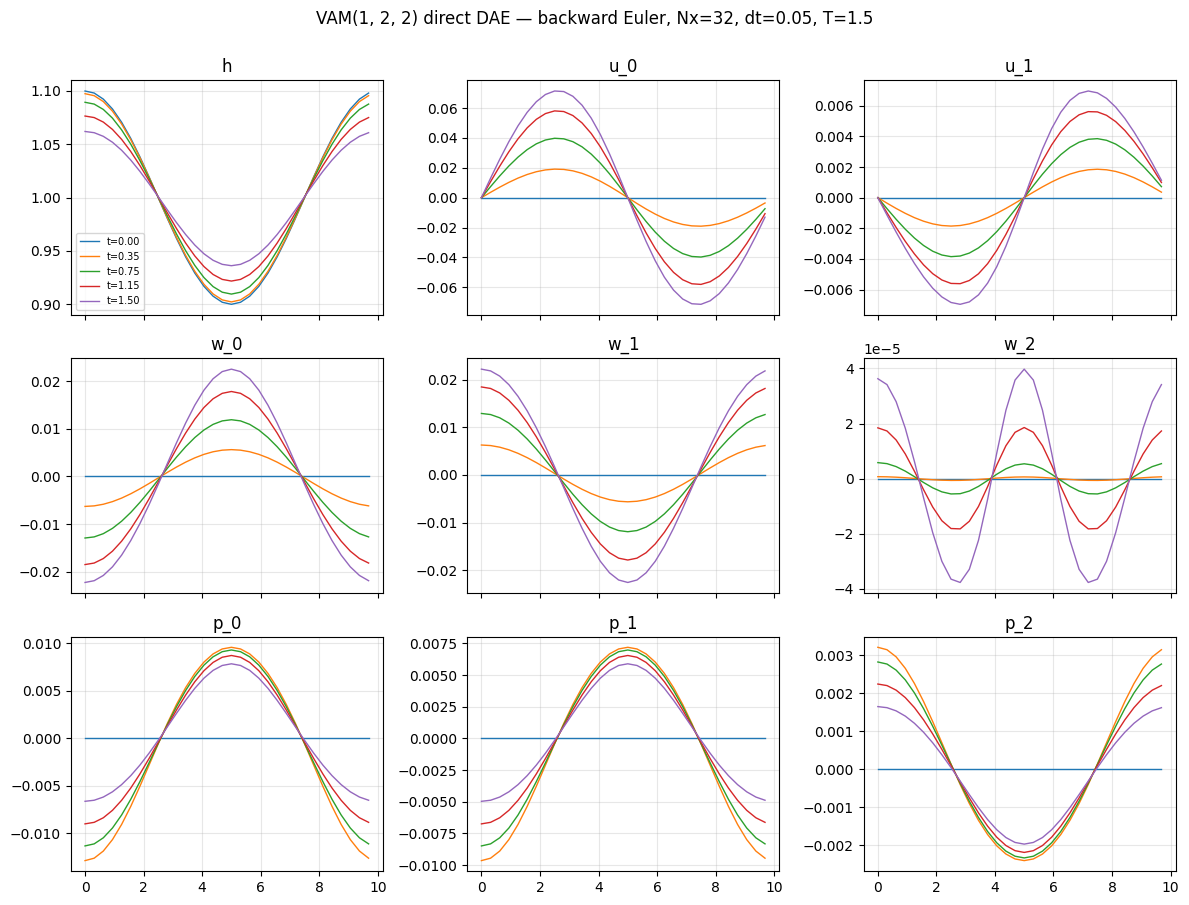

In [3]:
field_names = [f.func.__name__ for f in stepper.fields]
fig, axes = plt.subplots(3, 3, figsize=(12, 9), sharex=True)
x_grid = np.arange(stepper.Nx) * stepper.dx
t_show = [0, len(snapshots) // 4, len(snapshots) // 2,
          3 * len(snapshots) // 4, len(snapshots) - 1]
for k, ax in enumerate(axes.flat):
    if k >= len(field_names):
        ax.axis("off"); continue
    for ti in t_show:
        t, Qs = snapshots[ti]
        ax.plot(x_grid, Qs[:, k], lw=1.0, label=f"t={t:.2f}")
    ax.set_title(field_names[k])
    ax.grid(True, alpha=0.3)
    if k == 0:
        ax.legend(fontsize=7)
fig.suptitle("VAM(1, 2, 2) direct DAE — backward Euler, Nx=32, dt=0.05, T=1.5",
             y=1.00)
fig.tight_layout()
plt.show()

## Mass conservation and Newton convergence

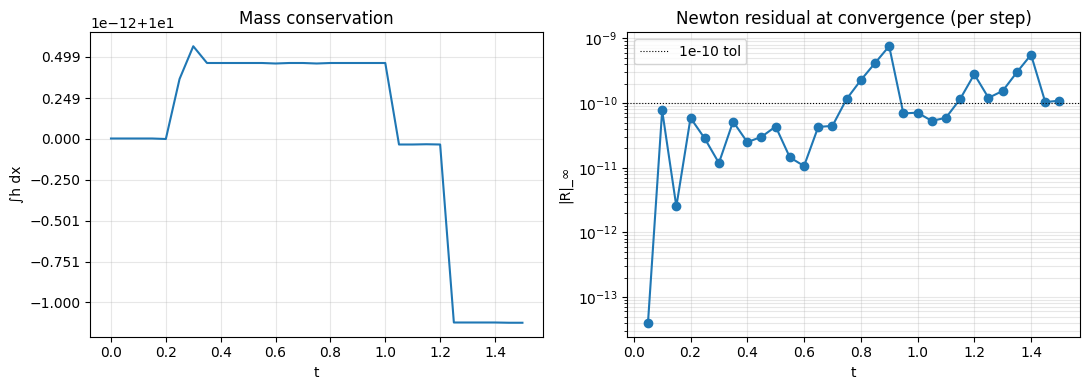

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(np.linspace(0, T, n_steps + 1), mass_history)
axes[0].set_title("Mass conservation")
axes[0].set_xlabel("t"); axes[0].set_ylabel("∫h dx")
axes[0].grid(True, alpha=0.3)
axes[1].semilogy(np.arange(1, n_steps + 1) * dt, newton_residuals, "o-")
axes[1].axhline(1e-10, color="k", ls=":", lw=0.8, label="1e-10 tol")
axes[1].set_title("Newton residual at convergence (per step)")
axes[1].set_xlabel("t"); axes[1].set_ylabel("|R|_∞")
axes[1].legend(); axes[1].grid(True, alpha=0.3, which="both")
fig.tight_layout()
plt.show()

## What's next

Working: backward-Euler direct-DAE on VAM(1, 2, 2).  Remaining work:

1. **Upgrade time integrator from backward Euler to ARS343.**  The
   toy already verifies ARS343's 3rd-order convergence on nonlinear
   DAEs; wrapping the per-step Newton in the ARS stage loop is
   mechanical.  Pareschi-Russo / Gardner ARK pattern.

2. **IMEX split.**  Currently everything is implicit.  Split off the
   advective hyperbolic flux as `f_E` (explicit, reusing the existing
   `HyperbolicSolver` Riemann + non-conservative path) and keep the
   constraints + pressure-coupling implicit.  Allows larger time
   steps while keeping the constraint enforcement tight.

3. **Verification against `SplittingSolver`.**  Run the same
   initial condition through both `SplittingSolver` (Chorin
   projection) and `vam_dae_simulate.py` (direct DAE); compare
   velocity, pressure, and mass-conservation drift.  Expect:
   direct DAE matches splitting at the splitting-error
   tolerance (~1e-3 relative on smooth flows), exceeds it on
   short waves where splitting introduces dispersion error.

4. **Promote the prototype into `library/zoomy_core/zoomy_core/fvm/`**
   as `solver_dae_ark_numpy.py`, replacing the dead-code skeleton
   `solver_dae_numpy.py`.  Wire to the `FreeSurfaceFlowSolver`
   pattern so it lives next to `SplittingSolver` as an alternative
   integration path.